In [1]:
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

In [2]:
cwd = Path.cwd().parent
data_dir = cwd / 'data'

cmg_data = pd.read_csv(data_dir / 'AllScenarios_CMG.csv')

<Axes: >

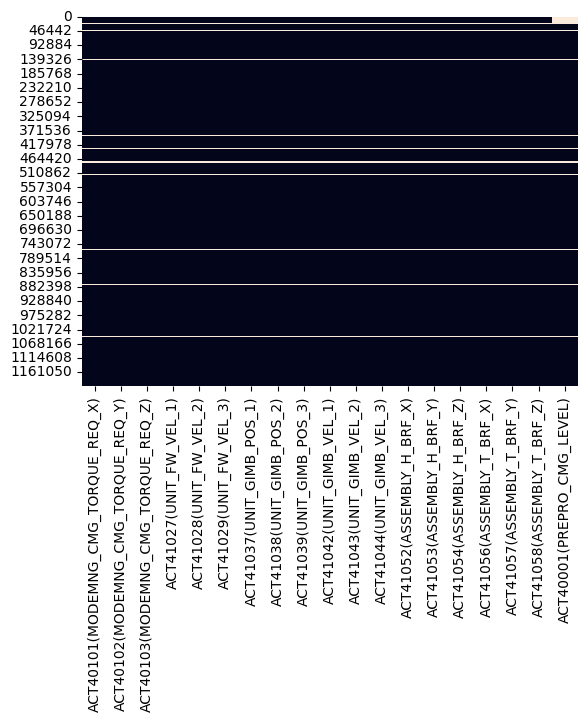

In [3]:
sns.heatmap(cmg_data.isnull(), cbar=False)

# Data Preprocessing


## Cleaning

In [3]:
cmg_cleaned = cmg_data.dropna(ignore_index = True)

## Splitting

In [19]:
import random

random_seed = 42

random.seed(random_seed)

print(random.random())

random.sample(
	range(10),
	5
)

0.6394267984578837


[0, 4, 3, 1, 6]

In [66]:
import random

random_seed = 10

random.seed(random_seed)

print(random.random())

random.sample(
	range(10),
	5
)

0.5714025946899135


[6, 7, 0, 1, 3]

In [ ]:
random.sample(
	range(10),
	5, 
	
)

[9, 7, 0, 6, 8]

In [124]:
import random
from itertools import chain

def split_indices(df, window_size, overlap, windows_per_chunk=100, 
				train_split=0.8, val_split=0.1, test_split=0.1,
				start_seed = 42
				) -> tuple[list[int], list[int], list[int]]:
	"""
	Split dataframe indices using chunk-based strategy.

	Args:
		df: Cleaned pandas DataFrame
		window_size: Size of sliding window
		overlap: Overlap fraction (0.0-0.99)
		windows_per_chunk: Number of windows per chunk
		train_split, val_split, test_split: Split ratios
		random_seed: Random seed for reproducibility

	Returns:
		tuple: (train_indices, val_indices, test_indices)
	"""
	random_seed = start_seed

	random.seed(random_seed)

	stride = max(1, int(window_size * (1 - overlap)))
	total_points = len(df)
	total_windows = (total_points - window_size) // stride + 1
	tot_chunks = total_windows // windows_per_chunk

	data_indices = df.index.tolist()
	test_points = test_split * total_points
	val_points = val_split * total_points

	# Test set
	test_indices = data_indices[-int(test_points):]
	train_val_indices = data_indices[:-int(test_points)]

	train_val_block_chunks = [
		train_val_indices[i:i + tot_chunks] 
		for i in range(0, len(train_val_indices), tot_chunks)
	]

	# Adjusted original validation set percentage
	sample_percentage = round(val_points/len(train_val_indices), 2)

	# List of all block chunks indices
	block_chunks_indices = list(range(0, len(train_val_block_chunks)))

	# Validation set
	val_block_chunks_indices = sorted(random.sample(
			block_chunks_indices,
			k = int(len(train_val_block_chunks) * sample_percentage)
		)
	)
	val_dataset_blocks_indices = [
		train_val_block_chunks[i] for i in val_block_chunks_indices
	]

	val_indices = list(chain.from_iterable(val_dataset_blocks_indices))

	# Train set
	train_block_chunks_indices = [
		x for x in block_chunks_indices 
		if x not in set(val_block_chunks_indices)
	]

	train_dataset_blocks_indices = [
		train_val_block_chunks[i] for i in train_block_chunks_indices
	]

	train_indices = list(
		chain.from_iterable(train_dataset_blocks_indices)
	)
	
	return train_indices, val_indices, test_indices

In [132]:
train_indices, val_indices, test_indices = split_indices(
	df = cmg_cleaned, 
	window_size = 16,
	overlap = 0.8,
	windows_per_chunk= 100,
	train_split= 0.8,
	val_split= 0.1,
	test_split= 0.1
)

In [117]:
print(
	"\n train_indices", len(train_indices),
	"\n val_indices", len(val_indices),
	"\n test_indices", len(test_indices)
)


 train_indices 924920 
 val_indices 111273 
 test_indices 115132


In [140]:
train_df = cmg_cleaned.loc[train_indices,:].copy()
val_df = cmg_cleaned.loc[val_indices,:].copy()
test_df = cmg_cleaned.loc[test_indices,:].copy()

### Visualize splits

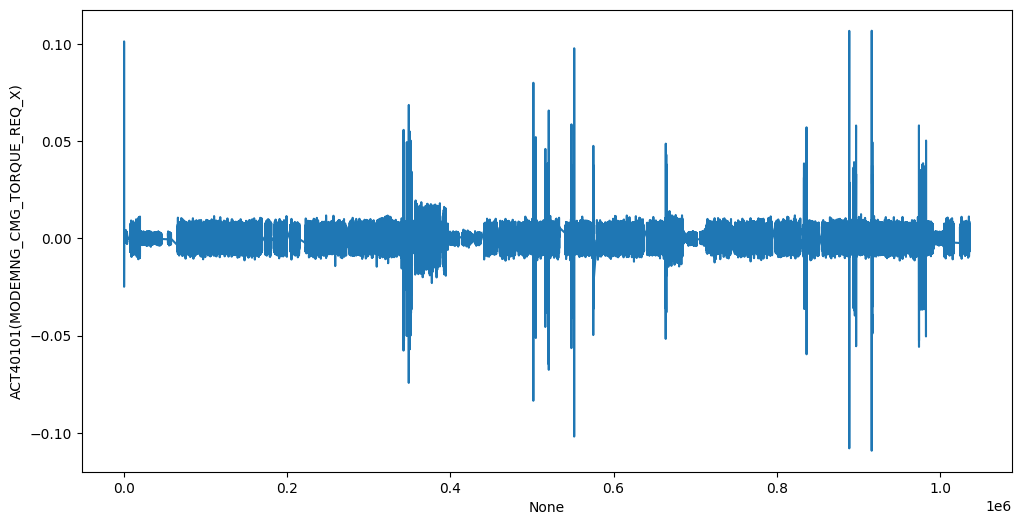

In [ ]:
data_to_plot = train_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot,
    x=data_to_plot.index,
    y=data_to_plot.columns[feature]
)

plt.show()

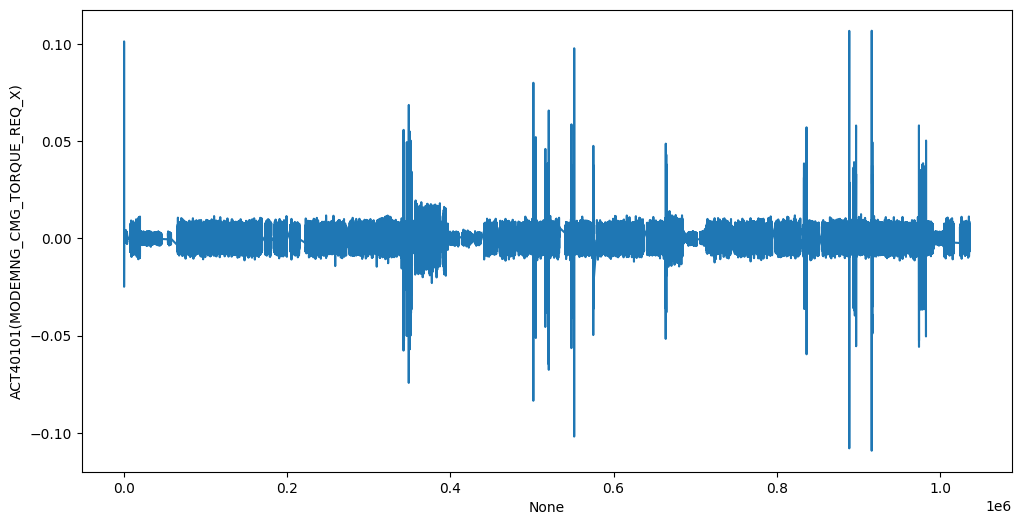

In [ ]:
data_to_plot = train_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot,
    x=data_to_plot.index,
    y=data_to_plot.columns[feature]
)

plt.show()

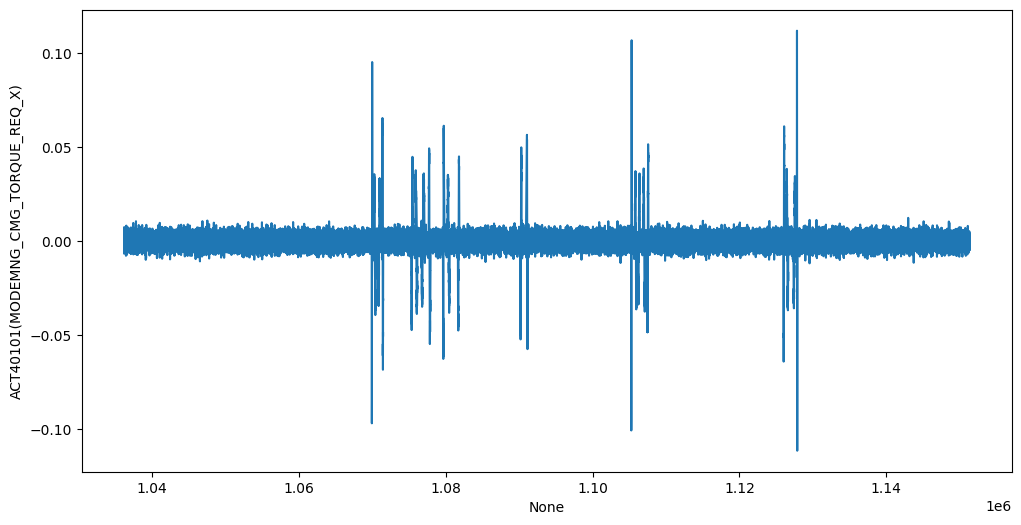

In [ ]:
data_to_plot = test_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot,
    x=data_to_plot.index,
    y=data_to_plot.columns[feature]
)

plt.show()

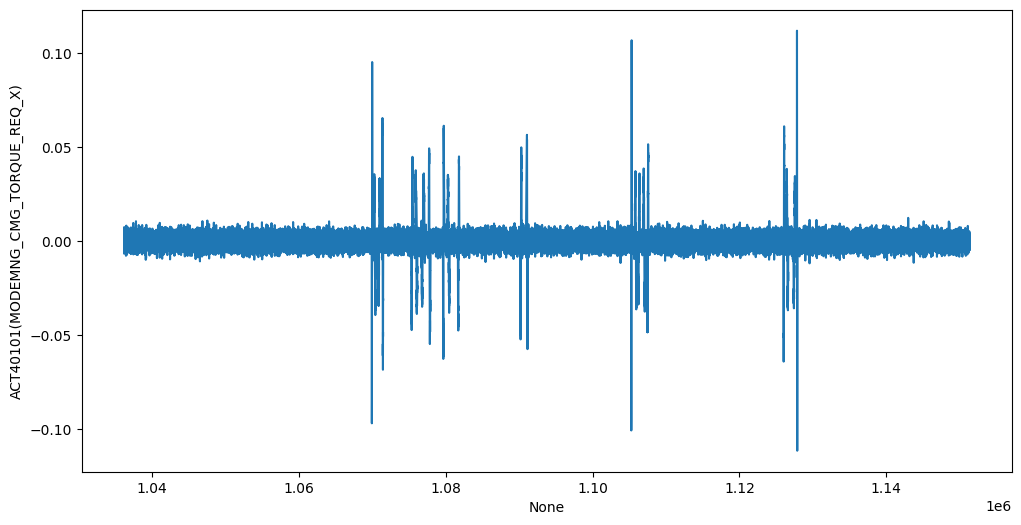

In [ ]:
data_to_plot = test_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot,
    x=data_to_plot.index,
    y=data_to_plot.columns[feature]
)

plt.show()

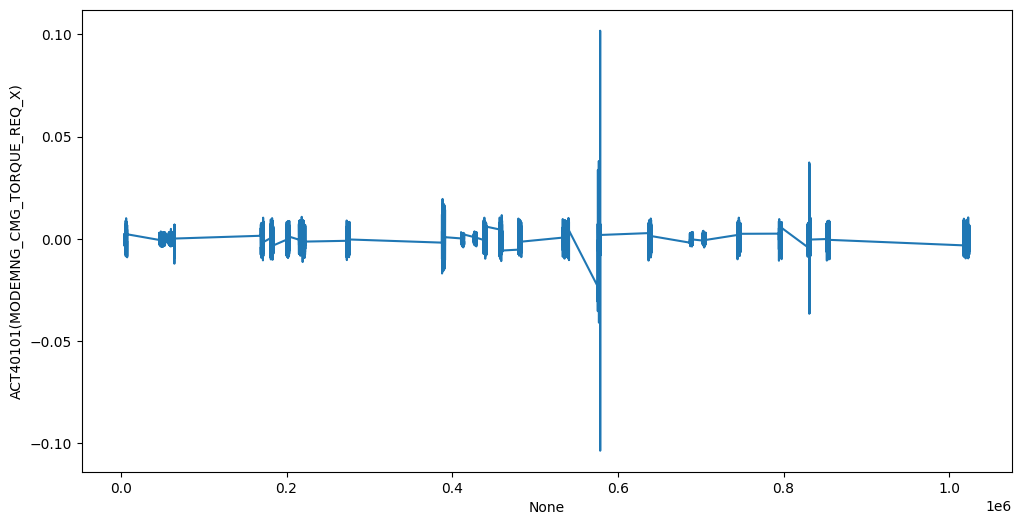

In [ ]:
data_to_plot = val_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot,
    x=data_to_plot.index,
    y=data_to_plot.columns[feature]
)

plt.show()

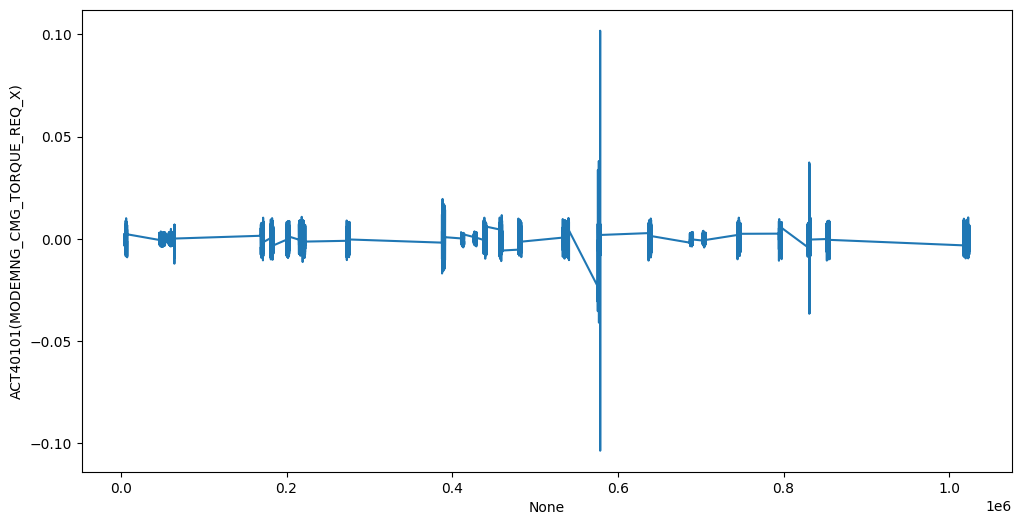

In [142]:
data_to_plot = val_df
feature = 0

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=data_to_plot,
    x=data_to_plot.index,
    y=data_to_plot.columns[feature]
)

plt.show()

## Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_std = scaler.fit_transform(train_df).astype(np.float32)
val_std = scaler.transform(val_df).astype(np.float32)
test_std = scaler.transform(test_df).astype(np.float32)

print(
	"\n train_std.shape", train_std.shape,
	"\n val_std.shape", val_std.shape,
	"\n test_std.shape", test_std.shape
)


 train_std.shape (924920, 19) 
 val_std.shape (111273, 19) 
 test_std.shape (115132, 19)


## Sequencing

In [204]:
window_size = 16
overlap = 0.8

lenght = train_std.shape[0]
# lenght = 4

stride = max(1, int(window_size * (1 - overlap)))
num_windows = (
	(lenght - window_size) // stride
	) + 1


print(
	"\n num_windows", num_windows,
	"\n stride", stride
)


 num_windows 308302 
 stride 3


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

class SignalWindowDataset(Dataset):
	"""Memory-efficient dataset that creates windows on-the-fly"""

	def __init__(self, std_data, window_size=16, overlap=0.0, n_signals=19):
		"""
		Args:
			std_data: Standardized pandas DataFrame
			window_size: Number of time points per window (default: 16)
			overlap: Overlap fraction between windows, 0.0 to 0.99 (default: 0.0)
			n_signals: Number of signal channels (default: 19)
		"""

		self.data = std_data
		# TODO: handle case where window_size is greater than data.shape[0]
		self.window_size = window_size
		self.n_signals = n_signals

		# Calculate stride based on overlap
		# TODO: handle case where overlap is 0
		# TODO: handle case where overlap is greater than 1
		# TODO: handle case where overlap is negative
		self.stride = max(1, int(window_size * (1 - overlap)))

		# Calculate number of windows
		self.n_windows = (
			(self.data.shape[0] - window_size) // self.stride
			) + 1

	def __len__(self):
		return self.n_windows

	def __getitem__(self, idx):
		start = idx * self.stride
		end = start + self.window_size
		window = self.data[start:end, :].T
		window = window[np.newaxis, :, :]
		return torch.from_numpy(window)

In [ ]:
train_seq = SignalWindowDataset(
	std_data = train_std,
	window_size = 16,
	overlap = 0.8,
	n_signals = train_std.shape[1]
)

train_loader = DataLoader(
	train_seq,
	batch_size = 32,
	shuffle = False,
	num_workers = 4
)

train_batch = next(iter(train_loader))
train_batch.shape

# Model

In [4]:
from models.conv_ae2D import CONV_AE2D

ModuleNotFoundError: No module named 'ray'